# Monte Carlo Methods for Reinforcement Learning — From Grid Worlds to Reasoning LLMs

**Based on the supplied lecture transcript.**

This notebook reconstructs the lecture's core ideas through intuition, formal mathematics, from-scratch Python, visualizations, experiments, failure cases, and connections to reasoning LLMs.

### Source labels
> **Fact from the lecture** — directly grounded in the supplied transcript.

> **Additional explanation** — added for intuition or mathematical precision.

> **Implementation assumption** — a simplification used to make the algorithms inspectable.

## Learning goals
1. Understand why Monte Carlo (MC) differs from Dynamic Programming (DP).
2. Estimate state values from complete episodes.
3. Estimate action values and perform MC control.
4. Study exploration vs. exploitation with epsilon-greedy behavior.
5. Understand on-policy and off-policy learning.
6. Build intuition for importance sampling.
7. Connect complete RL trajectories to reasoning trajectories in LLMs.

# 1. Model-Based vs. Experience-Based Learning

> **Fact from the lecture:** DP depends on knowledge of the environment model; Monte Carlo learns from experience and does not require prior transition probabilities.

| Method | Needs environment model? | Waits for complete episode? | Bootstraps? |
|---|---:|---:|---:|
| Dynamic Programming | Yes | No | Yes |
| Monte Carlo | No | Yes | No |

## Intuition first

DP can ask: *“If I take this action, what states might follow, and with what probabilities?”*

MC instead says: *“I do not know in advance. I will try trajectories, observe what happens, and average outcomes.”*

The discounted return from time step \(t\) is

$$
G_t=\sum_{k=0}^{T-t-1}\gamma^kR_{t+k+1}.
$$

Where:
- \(G_t\): total future return,
- \(T\): terminal time,
- \(R_{t+k+1}\): future reward,
- \(\gamma\in[0,1]\): discount factor.

For a policy \(\pi\),

$$
V^\pi(s)=\mathbb E_\pi[G_t\mid S_t=s].
$$

DP uses the next state's estimate in a Bellman equation; that is bootstrapping. MC uses sampled complete returns directly.

## Connection to Reasoning LLMs

An autoregressive LLM can be viewed conceptually as a policy

$$
\pi_\theta(a_t\mid s_t),
$$

where \(s_t\) is the prompt plus generated prefix and \(a_t\) is the next token.

A complete reasoning trajectory resembles an episode:

$$
\text{prompt}\rightarrow\text{reasoning tokens}\rightarrow\text{final answer}\rightarrow\text{reward}.
$$

A correctness or verifier score can play the role of an episode-level reward. This makes MC a useful conceptual model for learning from complete reasoning trajectories.

**Limitation:** real LLMs do not use a literal value table for every text prefix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
rng = np.random.default_rng(7)

# 2. A Grid World Implemented From Scratch

> **Implementation assumption:** We use a deterministic episodic grid with four actions, obstacles, a terminal goal, and a small negative step cost.

This is intentionally small so the learning logic remains visible.

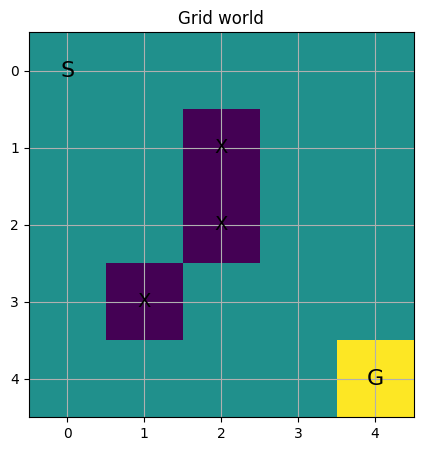

In [2]:
class GridWorld:
    ACTIONS = {0: (-1,0), 1: (1,0), 2: (0,-1), 3: (0,1)}
    ACTION_NAMES = ["↑", "↓", "←", "→"]

    def __init__(self, shape=(5,5), start=(0,0), goal=(4,4),
                 obstacles={(1,2),(2,2),(3,1)}, step_reward=-0.04,
                 goal_reward=1.0, obstacle_reward=-1.0, max_steps=100):
        self.shape = shape
        self.start = start
        self.goal = goal
        self.obstacles = set(obstacles)
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.obstacle_reward = obstacle_reward
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.state = self.start
        self.steps = 0
        return self.state

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.state
        nr, nc = r + dr, c + dc
        next_state = self.state if not (0 <= nr < self.shape[0] and 0 <= nc < self.shape[1]) else (nr, nc)
        self.steps += 1
        self.state = next_state

        if next_state in self.obstacles:
            return next_state, self.obstacle_reward, True
        if next_state == self.goal:
            return next_state, self.goal_reward, True
        if self.steps >= self.max_steps:
            return next_state, self.step_reward, True
        return next_state, self.step_reward, False

def plot_grid(env, title="Grid world", trajectory=None):
    canvas = np.zeros(env.shape)
    for s in env.obstacles: canvas[s] = -1
    canvas[env.goal] = 1
    plt.figure(figsize=(5,5))
    plt.imshow(canvas, interpolation="nearest")
    plt.xticks(range(env.shape[1])); plt.yticks(range(env.shape[0])); plt.grid(True)
    plt.text(env.start[1], env.start[0], "S", ha="center", va="center", fontsize=16)
    plt.text(env.goal[1], env.goal[0], "G", ha="center", va="center", fontsize=16)
    for r,c in env.obstacles: plt.text(c,r,"X",ha="center",va="center",fontsize=14)
    if trajectory:
        plt.plot([s[1] for s in trajectory],[s[0] for s in trajectory], marker="o")
    plt.title(title); plt.show()

env = GridWorld()
plot_grid(env)

# 3. Monte Carlo Prediction

> **Fact from the lecture:** Estimate a state's value by observing returns from repeated episodes and averaging them.

The estimator is

$$
\hat V(s)=\frac{1}{N(s)}\sum_{i=1}^{N(s)}G^{(i)}(s).
$$

Rather than storing every past return, we use the incremental sample mean

$$
V_n=V_{n-1}+\frac{1}{n}(G_n-V_{n-1}).
$$

Here \(n\) is the number of samples for that state.

**Additional explanation:** We implement first-visit MC: only the first occurrence of a state in an episode contributes an update.

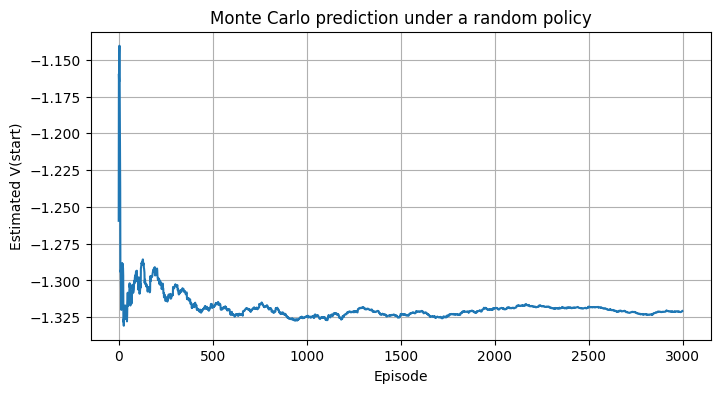

In [3]:
def random_policy(state, n_actions=4):
    return int(rng.integers(n_actions))

def generate_episode(env, policy):
    state = env.reset()
    episode = []
    for _ in range(env.max_steps):
        action = policy(state)
        next_state, reward, done = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if done: break
    return episode

def discounted_returns(episode, gamma=0.99):
    returns = np.zeros(len(episode))
    G = 0.0
    for t in reversed(range(len(episode))):
        G = episode[t][2] + gamma * G
        returns[t] = G
    return returns

def mc_prediction(env, policy, episodes=5000, gamma=0.99):
    V = defaultdict(float)
    counts = defaultdict(int)
    history = []
    for _ in range(episodes):
        episode = generate_episode(env, policy)
        returns = discounted_returns(episode, gamma)
        seen = set()
        for t, (state, _, _) in enumerate(episode):
            if state not in seen:
                seen.add(state)
                counts[state] += 1
                n = counts[state]
                V[state] += (returns[t] - V[state]) / n
        history.append(V[env.start])
    return V, counts, np.asarray(history)

V, counts, history = mc_prediction(env, random_policy, episodes=3000)
plt.figure(figsize=(8,4))
plt.plot(history)
plt.xlabel("Episode"); plt.ylabel("Estimated V(start)")
plt.title("Monte Carlo prediction under a random policy")
plt.grid(True); plt.show()

## Connection to Reasoning LLMs

A partial reasoning prefix can be viewed as a state. A complete sampled continuation produces an outcome. Averaging many outcomes gives a conceptual estimate of how promising the prefix is.

| RL | Reasoning LLM |
|---|---|
| State | Prompt + generated prefix |
| Action | Next token / reasoning move |
| Episode | Complete solution |
| Return | Future reward |
| Policy | Token distribution |

**Inference-time compute:** generating more candidate trajectories can reveal more of the distribution of possible outcomes, at increased computational cost.

# 4. From State Values to Action Values

> **Fact from the lecture:** \(V^\pi(s)\) does not directly tell us which action to choose. For control we need

$$
Q^\pi(s,a)=\mathbb E_\pi[G_t\mid S_t=s,A_t=a].
$$

Intuition:

- \(V^\pi(s)\): “How good is this state?”
- \(Q^\pi(s,a)\): “How good is taking this action in this state?”

The control problem can therefore improve a policy by preferring actions with larger estimated \(Q\)-values.

## Connection to Reasoning LLMs

Conceptually, \(Q(s,a)\) asks how promising a particular next token or reasoning move is, given the current prefix and future continuation policy.

Real LLMs cannot enumerate and tabulate every prefix-token pair, but the control intuition is directly relevant.

# 5. Epsilon-Greedy Exploration and On-Policy MC Control

> **Fact from the lecture:** Most of the time choose the action with the largest estimated value, but occasionally choose randomly.

With probability \(1-\epsilon\), exploit:

$$
a=\arg\max_aQ(s,a).
$$

With probability \(\epsilon\), explore a random action.

Too little exploration can trap the agent in early bad beliefs. Too much exploration can prevent reliable exploitation.

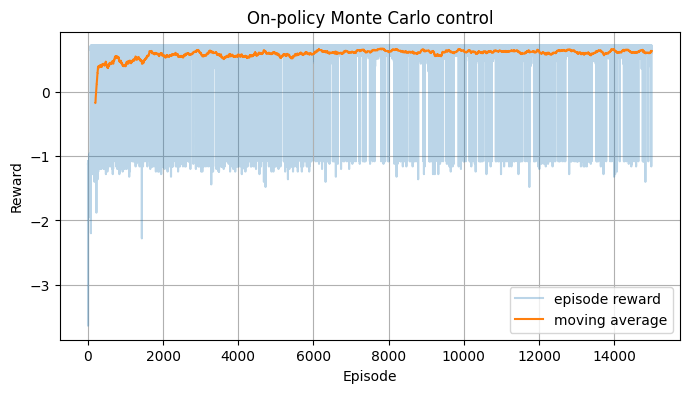

In [4]:
def epsilon_greedy_action(Q, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(4))
    q = Q[state]
    best = np.flatnonzero(q == q.max())
    return int(rng.choice(best))

def generate_episode_from_q(env, Q, epsilon, rng):
    state = env.reset()
    episode = []
    for _ in range(env.max_steps):
        action = epsilon_greedy_action(Q, state, epsilon, rng)
        next_state, reward, done = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if done: break
    return episode

def mc_control(env, episodes=20000, epsilon=0.1, gamma=0.99, seed=0):
    local_rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(4))
    counts = defaultdict(lambda: np.zeros(4, dtype=int))
    rewards, successes = [], []
    success_count = 0

    for ep in range(episodes):
        episode = generate_episode_from_q(env, Q, epsilon, local_rng)
        returns = discounted_returns(episode, gamma)
        rewards.append(sum(x[2] for x in episode))
        if episode[-1][2] == env.goal_reward:
            success_count += 1
        successes.append(success_count/(ep+1))

        seen = set()
        for t, (state, action, _) in enumerate(episode):
            key = (state, action)
            if key not in seen:
                seen.add(key)
                counts[state][action] += 1
                n = counts[state][action]
                Q[state][action] += (returns[t]-Q[state][action])/n
    return Q, np.asarray(rewards), np.asarray(successes)

Q, rewards, success = mc_control(env, episodes=15000, epsilon=0.1, seed=1)

plt.figure(figsize=(8,4))
plt.plot(rewards, alpha=0.3, label="episode reward")
window=200
moving=np.convolve(rewards,np.ones(window)/window,mode="valid")
plt.plot(np.arange(window-1,len(rewards)),moving,label="moving average")
plt.xlabel("Episode"); plt.ylabel("Reward")
plt.title("On-policy Monte Carlo control")
plt.legend(); plt.grid(True); plt.show()

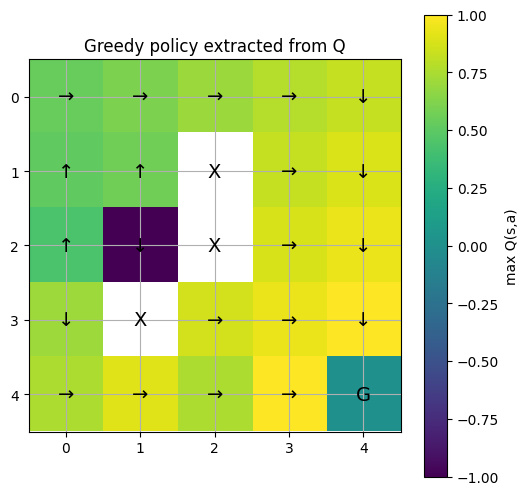

In [5]:
def plot_policy(env, Q):
    values = np.zeros(env.shape)
    for r in range(env.shape[0]):
        for c in range(env.shape[1]):
            s=(r,c)
            values[s] = np.nan if s in env.obstacles else np.max(Q[s])
    plt.figure(figsize=(6,6))
    plt.imshow(values, interpolation="nearest")
    plt.colorbar(label="max Q(s,a)")
    for r in range(env.shape[0]):
        for c in range(env.shape[1]):
            s=(r,c)
            if s in env.obstacles: label="X"
            elif s == env.goal: label="G"
            else: label=env.ACTION_NAMES[int(np.argmax(Q[s]))]
            plt.text(c,r,label,ha="center",va="center",fontsize=14)
    plt.xticks(range(env.shape[1])); plt.yticks(range(env.shape[0])); plt.grid(True)
    plt.title("Greedy policy extracted from Q")
    plt.show()

plot_policy(env,Q)

## Connection to Reasoning LLMs

Exploration can correspond conceptually to sampling alternative reasoning continuations rather than always selecting the currently preferred continuation.

- exploitation: follow the best currently estimated trajectory;
- exploration: sample alternatives;
- more inference-time compute: generate and evaluate more candidates.

This is only an analogy: real LLM decoding and RL optimization use richer mechanisms than literal epsilon-greedy token selection.

# 6. Experiment: Exploration vs. Exploitation

Change \(\epsilon\) and compare learning curves. There is no universal best value; performance depends on the environment, reward structure, sample budget, and randomness.

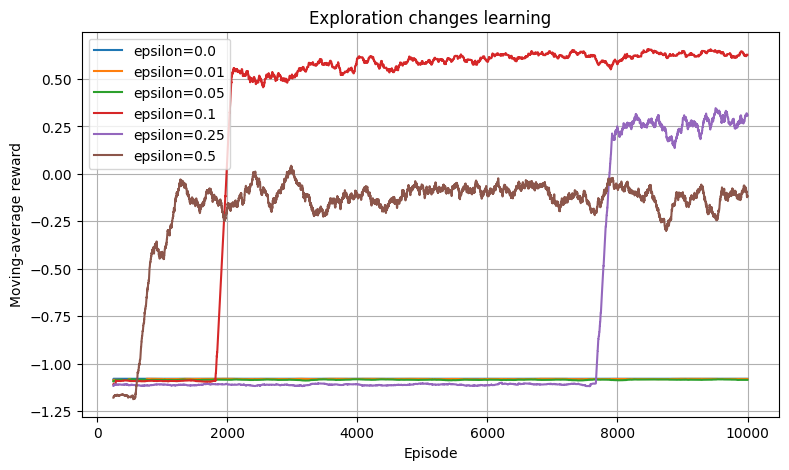

epsilon=0.0: final 1000-episode mean reward = -1.080
epsilon=0.01: final 1000-episode mean reward = -1.081
epsilon=0.05: final 1000-episode mean reward = -1.085
epsilon=0.1: final 1000-episode mean reward = 0.632
epsilon=0.25: final 1000-episode mean reward = 0.281
epsilon=0.5: final 1000-episode mean reward = -0.133


In [6]:
epsilons=[0.0,0.01,0.05,0.1,0.25,0.5]
results={}
for eps in epsilons:
    _, r, s = mc_control(GridWorld(), episodes=10000, epsilon=eps, seed=42)
    results[eps]=(r,s)

plt.figure(figsize=(9,5))
window=250
for eps,(r,s) in results.items():
    m=np.convolve(r,np.ones(window)/window,mode="valid")
    plt.plot(np.arange(window-1,len(r)),m,label=f"epsilon={eps}")
plt.xlabel("Episode"); plt.ylabel("Moving-average reward")
plt.title("Exploration changes learning")
plt.legend(); plt.grid(True); plt.show()

for eps,(r,_) in results.items():
    print(f"epsilon={eps}: final 1000-episode mean reward = {r[-1000:].mean():.3f}")

### What to observe
- \(\epsilon=0\): pure exploitation; vulnerable to poor early estimates.
- very large \(\epsilon\): broad exploration but persistent random behavior.
- moderate \(\epsilon\): often provides a useful balance.

### Exercise 1
Repeat the experiment across multiple random seeds. Is your “best epsilon” conclusion robust?

# 7. Convergence and Coverage

MC convergence is empirical here: estimates become more stable as relevant experiences accumulate.

A key point is that **episode count is not the same as sample count for every state-action pair**. Some pairs may remain poorly explored.

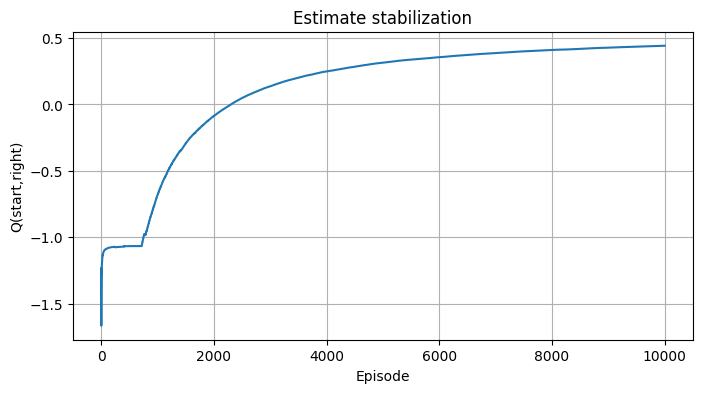

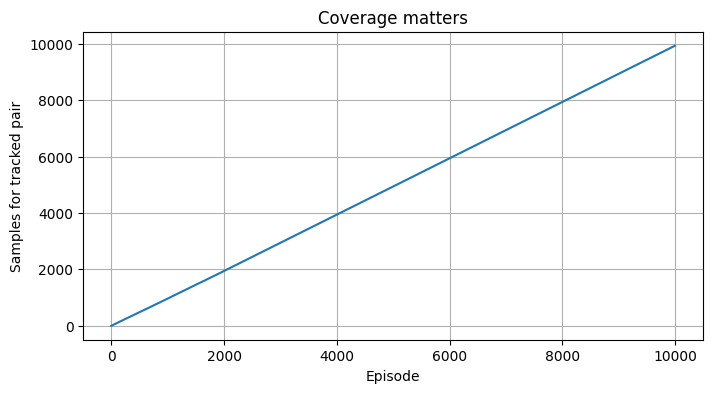

In [7]:
def track_q(env, episodes=10000, epsilon=0.1, gamma=0.99, seed=9):
    local_rng=np.random.default_rng(seed)
    Q=defaultdict(lambda:np.zeros(4))
    counts=defaultdict(lambda:np.zeros(4,dtype=int))
    estimates=[]; visits=[]
    tracked_state=env.start; tracked_action=3

    for _ in range(episodes):
        episode=generate_episode_from_q(env,Q,epsilon,local_rng)
        returns=discounted_returns(episode,gamma)
        seen=set()
        for t,(s,a,_) in enumerate(episode):
            if (s,a) not in seen:
                seen.add((s,a))
                counts[s][a]+=1
                Q[s][a]+=(returns[t]-Q[s][a])/counts[s][a]
        estimates.append(Q[tracked_state][tracked_action])
        visits.append(counts[tracked_state][tracked_action])
    return np.array(estimates),np.array(visits)

estimates,visits=track_q(GridWorld())
plt.figure(figsize=(8,4))
plt.plot(estimates); plt.xlabel("Episode"); plt.ylabel("Q(start,right)")
plt.title("Estimate stabilization"); plt.grid(True); plt.show()

plt.figure(figsize=(8,4))
plt.plot(visits); plt.xlabel("Episode"); plt.ylabel("Samples for tracked pair")
plt.title("Coverage matters"); plt.grid(True); plt.show()

### Exercise 2
Track the least-visited and most-visited state-action pairs. Compare estimate stability and return variance.

# 8. Failure Cases

## A. Insufficient exploration
A greedy policy can stop trying actions that were unlucky early.

## B. Long episodes
MC waits for completion before assigning a complete return, delaying learning.

## C. High-variance returns
Different futures from similar state-action choices can produce noisy estimates.

## D. Reward misspecification
The agent optimizes the reward actually supplied, not the designer's unstated intent.

The experiment below makes navigation harder.

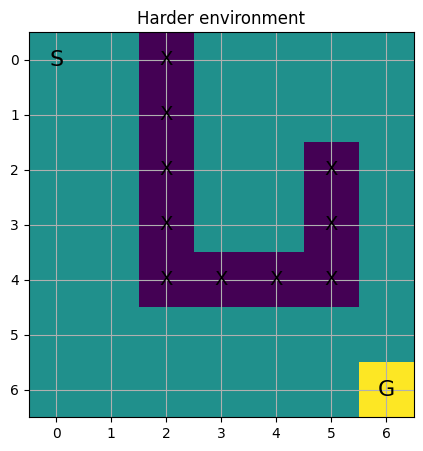

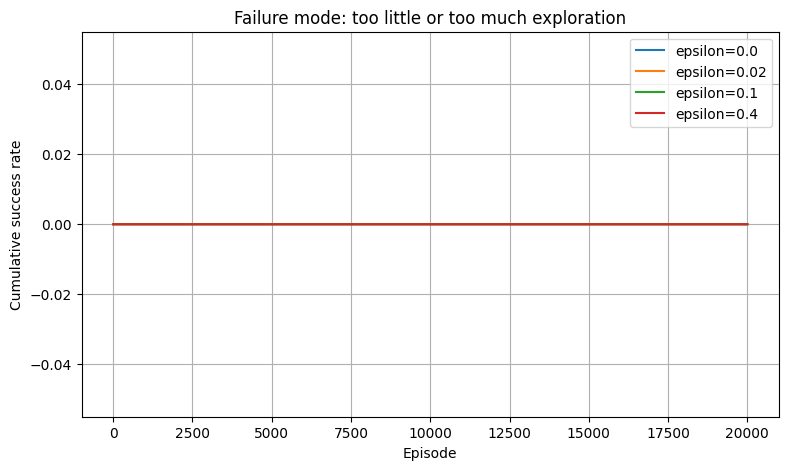

In [8]:
hard_env=GridWorld(
    shape=(7,7), start=(0,0), goal=(6,6),
    obstacles={(0,2),(1,2),(2,2),(3,2),(4,2),(4,3),(4,4),(2,5),(3,5),(4,5)},
    step_reward=-0.02, goal_reward=1.0, obstacle_reward=-1.0, max_steps=150
)
plot_grid(hard_env,"Harder environment")

failure_eps=[0.0,0.02,0.1,0.4]
plt.figure(figsize=(9,5))
for eps in failure_eps:
    _,r,s=mc_control(hard_env,episodes=20000,epsilon=eps,seed=3)
    plt.plot(s,label=f"epsilon={eps}")
plt.xlabel("Episode"); plt.ylabel("Cumulative success rate")
plt.title("Failure mode: too little or too much exploration")
plt.legend(); plt.grid(True); plt.show()

## Connection to Reasoning LLMs

- insufficient exploration: repeatedly using familiar but suboptimal reasoning patterns;
- long trajectories: delayed credit assignment;
- high variance: different sampled chains of thought can have very different outcomes;
- reward misspecification: optimizing a proxy can diverge from genuinely correct reasoning.

Extra inference-time compute can improve trajectory search, but it cannot automatically repair a bad reward.

# 9. On-Policy vs. Off-Policy

> **Fact from the lecture:** On-policy learning uses the same policy for data generation and optimization. Off-policy learning separates a behavior policy from a target policy.

Let:
- \(\mu\): behavior policy that generated the data;
- \(\pi\): target policy we want to evaluate.

On-policy:
$$
\mu=\pi.
$$

Off-policy:
$$
\mu\ne\pi.
$$

For reasoning LLMs, stored trajectories from an older model or another generator are conceptually off-policy relative to the current target model.

# 10. Importance Sampling

> **Fact from the lecture:** Relative probabilities between target and behavior policies are used to correct off-policy estimates.

For one decision:

$$
\rho=\frac{\pi(a\mid s)}{\mu(a\mid s)}.
$$

For a trajectory:

$$
\rho_{t:T-1}=\prod_{k=t}^{T-1}\frac{\pi(A_k\mid S_k)}{\mu(A_k\mid S_k)}.
$$

A weighted return contribution can therefore use \(\rho G\).

**Additional explanation:** large ratios can cause high variance. This is a central practical difficulty of importance sampling.

In [9]:
def importance_ratio(target_probs, behavior_probs, actions):
    ratio=1.0
    for t,a in enumerate(actions):
        mu=behavior_probs[t,a]
        if mu==0:
            raise ValueError("Sampled action had zero behavior probability.")
        ratio*=target_probs[t,a]/mu
    return ratio

target=np.array([[0.7,0.3],[0.9,0.1]])
behavior=np.array([[0.5,0.5],[0.6,0.4]])
actions=[0,0]
rho=importance_ratio(target,behavior,actions)
print("Trajectory ratio:",rho)
print("Weighted contribution for return G=2:",rho*2)

Trajectory ratio: 2.0999999999999996
Weighted contribution for return G=2: 4.199999999999999


## Connection to Reasoning LLMs

Off-policy reasoning data is attractive because successful trajectories can be reused. The difficulty is distribution mismatch: a trajectory likely under one policy may be unlikely under another.

Importance weighting is the conceptual tool introduced in the lecture for accounting for this mismatch.

# 11. Assumptions and Limitations

1. **Tabular values:** real LLMs need neural function approximation.
2. **Four actions:** LLMs have enormous token action spaces.
3. **Exact states:** text prefixes require generalization rather than exact table lookup.
4. **Simple rewards:** real reasoning rewards can come from verifiers, outcome labels, process signals, or learned evaluators.
5. **Terminal episodes:** real generation may be truncated or receive partial feedback.
6. **No advanced methods introduced:** policy gradients, actor-critic methods, replay, and modern LLM RL are intentionally omitted unless treated as optional next steps.

This notebook stays close to the lecture's conceptual scope.

# 12. Questions to Answer Without Looking Back

1. Why does DP need an environment model while MC does not?
2. What is bootstrapping?
3. Why must ordinary MC wait for an episode to finish?
4. What is the difference between \(V^\pi(s)\) and \(Q^\pi(s,a)\)?
5. Why can a purely greedy policy fail?
6. What does \(\epsilon\) control?
7. What is on-policy learning?
8. What is the behavior policy?
9. Why can importance sampling have high variance?
10. How can a reasoning trajectory resemble an RL episode?
11. Why can more inference-time compute help exploration?
12. Why does more search not automatically fix reward misspecification?

# 13. Small Exercises

## Exercise A — Every-visit MC
Remove the first-visit filter and update every occurrence.

## Exercise B — Decaying exploration
Implement

$$
\epsilon_k=\max(\epsilon_{\min},\epsilon_0\alpha^k).
$$

Compare fixed and decaying exploration.

## Exercise C — Reward sensitivity
Try step rewards \(0\), \(-0.001\), and \(-0.2\).

## Exercise D — Non-terminal obstacles
Give an obstacle penalty but continue the episode.

## Exercise E — Return variance
Store all returns for one state-action pair and plot sample mean and variance.

## Exercise F — Toy reasoning MDP
Create three reasoning moves, a terminal answer, and only terminal reward. Apply the same MC estimator.

# Key Takeaways

1. MC methods are **model-free** and learn from sampled experience.
2. MC estimates values by averaging **complete returns**.
3. \(V^\pi(s)\) evaluates states; \(Q^\pi(s,a)\) supports action selection.
4. Exploration is necessary to avoid permanently missing good actions.
5. Epsilon-greedy behavior is a simple exploration–exploitation mechanism.
6. On-policy learning uses the same policy for data generation and optimization.
7. Off-policy learning separates behavior and target policies.
8. Importance sampling corrects for probability mismatch but can have high variance.
9. MC does not bootstrap; it waits for complete sampled outcomes.

# Connection to Future Reasoning LLM Topics

The lecture motivates Temporal-Difference learning:

- DP: model-based + bootstrapping;
- MC: model-free + complete-return learning;
- TD: model-free + bootstrapping.

Future reasoning-LLM topics naturally include:

1. credit assignment across long reasoning traces;
2. value estimation for partial reasoning;
3. policy improvement from trajectory rewards;
4. on-policy versus off-policy trajectory reuse;
5. inference-time compute as trajectory search;
6. reward design and verifier reliability;
7. TD learning as a bridge between complete-return and bootstrapped updates.